# Задание 1
### Обработка данных

In [436]:
import pandas as pd
import numpy as np

In [437]:
df = pd.read_csv(r"data\players_data_light-2024_2025.csv", sep=',', header=0)

In [438]:
df.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Att (GK),Thr,Launch%,AvgLen,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist
0,1,Max Aarons,eng ENG,DF,Bournemouth,eng Premier League,24.0,2000.0,3,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Max Aarons,eng ENG,"DF,MF",Valencia,es La Liga,24.0,2000.0,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Rodrigo Abajas,es ESP,DF,Valencia,es La Liga,21.0,2003.0,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,James Abankwah,ie IRL,"DF,MF",Udinese,it Serie A,20.0,2004.0,6,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Keyliane Abdallah,fr FRA,FW,Marseille,fr Ligue 1,18.0,2006.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [439]:
columns = [ 'Age','90s','Sh','SoT','SoT%','Dist','PrgC','PrgP','xG']
df_clean = df[columns]

Признак Gls (голы) не использовался, так как он напрямую связан с xG, что привело бы к циклической зависимости

In [440]:
df_clean.head()

,Age,90s,Sh,SoT,SoT%,Dist,PrgC,PrgP,xG
0,24.0,1.0,0,0,NaN,NaN,1,8,0.0
1,24.0,1.3,0,0,NaN,NaN,0,6,0.0
2,21.0,0.7,1,0,0.0,24.5,3,2,0.1
3,20.0,1.0,1,0,0.0,15.0,3,4,0.1
4,18.0,0.0,0,0,NaN,NaN,1,0,0.0


- Age - возраст игрока
- 90s - количество сыгранных полных матчей (в пересчёте на 90 минут)
- Sh - общее количество ударов по воротам
- SoT - количество ударов в створ
- SoT% - процент ударов, пришедшихся в створ (точность ударов)
- Dist - средняя дистанция удара до ворот
- PrgC - количество продвижений мяча с ведением 
- PrgP - количество продвижений мяча передачами 

In [441]:
print("информация о датасете")
missing_info = pd.DataFrame({ 'Типы данных' : df_clean.dtypes, 'Пропусков':df_clean.isnull().sum()})

print(missing_info)
print(f"\nколичество пропущенных: {df_clean.isnull().sum().sum() }")
print(f"Размер: {df_clean.shape[0]} строк × {df_clean.shape[1]} колонок")

информация о датасете
     Типы данных  Пропусков
Age      float64          8
90s      float64          0
Sh         int64          0
SoT        int64          0
SoT%     float64        519
Dist     float64        519
PrgC       int64          0
PrgP       int64          0
xG       float64          0

количество пропущенных: 1046
Размер: 2854 строк × 9 колонок


In [442]:
df_clean = df_clean.dropna()
print(f"количество пропущенных: {df_clean.isnull().sum().sum()}")
print(f"Размер: {df_clean.shape[0]} строк × {df_clean.shape[1]} колонок")

количество пропущенных: 0
Размер: 2331 строк × 9 колонок


Применяем стандартизацию

In [443]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_clean[columns] = scaler.fit_transform(df_clean[columns])
df_clean.head()

,Age,90s,Sh,SoT,SoT%,Dist,PrgC,PrgP,xG
2,-0.964589,-1.411783,-0.896961,-0.796383,-1.486739,1.371350,-0.806139,-1.043215,-0.665390
3,-1.198244,-1.382041,-0.896961,-0.796383,-1.486739,-0.433285,-0.806139,-1.003722,-0.665390
5,2.540229,-0.341070,-0.845698,-0.667477,0.999265,-1.231124,-0.769823,-0.648286,-0.631911
6,-0.263626,1.651646,0.845984,0.234861,-0.348149,1.010423,2.970749,3.004805,1.443753
8,1.138302,0.055490,0.538405,0.621578,0.397652,-0.072358,0.355980,-0.253358,0.740706


- Целевая переменная:
xG — ожидаемое количество голов

In [444]:
X = df_clean.drop('xG', axis=1)
Y = df_clean['xG']

# Задание 2 

In [445]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=22
)

In [455]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """Универсальная функция для обучения 
    и вычислений метрик для моделей """
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    print(f"{name}")
    print(f"{'Метрика':<15} {'Train':<15} {'Test':<15}")
    print(f"{'MSE':<15} {train_mse:<15.4f} {test_mse:<15.4f}")
    print(f"{'MAE':<15} {train_mae:<15.4f} {test_mae:<15.4f}")
    print(f"{'R2':<15} {train_r2:<15.4f} {test_r2:<15.4f}")
    
    return {
        'model': model,
        'name': name,
        'y_train_pred': y_train_pred,
        'y_test_pred': y_test_pred,
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_mae' : train_mae,
        'test_mae': test_mae,
        'train_r2': train_r2,
        'test_r2': test_r2
    }

In [447]:
results_list = []

In [448]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, RANSACRegressor
from sklearn.preprocessing import PolynomialFeatures

In [449]:
results_list.append(evaluate_model(
    "Linear Regression",
    LinearRegression(),
    X_train, X_test, y_train, y_test
))

Linear Regression
Метрика         Train           Test           
MSE             0.1374          0.1218         
MAE             0.2262          0.2262         
R2              0.8634          0.8755         


Линейная регрессия показывает хорошие результаты, значение метрик на обучающей и тестовой выборках практически совпадают, что означает отсутствие переобучения. Значит что у нас линейная зависимость между компонентами и целевой переменной которую улавливает модель 

In [450]:
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)
results_list.append(evaluate_model(
    "Polynomial (degree=2)",
    LinearRegression(),
    X_train_poly2, X_test_poly2, y_train, y_test
))

Polynomial (degree=2)
Метрика         Train           Test           
MSE             0.0888          0.1002         
MAE             0.1764          0.1812         
R2              0.9116          0.8976         


У полиномиальной модели второй степени получились наилучшие результаты среди всех моделей. Снижение MSE и MAE, а также рост R2 показывает, что модель успешно учитывает нелинейные зависимости в данных. При этом разница между обучающей и тестовой выборками остаётся небольшой, что означает отсутствие переобучния.

In [451]:
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train)
X_test_poly3 = poly3.transform(X_test)
results_list.append(evaluate_model(
    "Polynomial (degree=3)",
    LinearRegression(),
    X_train_poly3, X_test_poly3, y_train, y_test
))

Polynomial (degree=3)
Метрика         Train           Test           
MSE             0.0728          0.1178         
MAE             0.1629          0.1928         
R2              0.9276          0.8796         


Полиномиальная модель третьей степени показывает более высокое качество на обучающей выборке, однако на тестовой выборке результаты ухудшаются по сравнению с моделью второй степени. Это признак переобучении (модель подстраиваться под шум в данных)

In [452]:
results_list.append(evaluate_model(
    "Lasso (alpha=0.01)",
    Lasso(alpha=0.01, random_state=22),
    X_train, X_test, y_train, y_test
))

Lasso (alpha=0.01)
Метрика         Train           Test           
MSE             0.1384          0.1241         
MAE             0.2210          0.2222         
R2              0.8624          0.8731         


У модель Lasso результаты, похоже на линейную регрессию, но немного хуже по всем метрикам. Это говорит о том, что регуляризация не даёт значительного преимущества, вероятно из-за отсутствия сильной корреляции между признаками.

In [464]:
alphas = np.logspace(-4, 2, 100) 

ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='r2')
ridge_cv.fit(X_train, y_train)

print("RIDGE - подбор alpha")
print(f"Лучший alpha: {ridge_cv.alpha_:.4f}")
print(f"Train R2: {ridge_cv.score(X_train, y_train):.4f}")
print(f"Test R2: {ridge_cv.score(X_test, y_test):.4f}")

RIDGE - подбор alpha
Лучший alpha: 14.1747
Train R2: 0.8632
Test R2: 0.8750


Ridge-регрессия практически полностью повторяет результаты линейной модели. Это также подтверждает, что признаки не требуют сильной регуляризации, а модель уже хорошо обобщает данные.

In [454]:
results_list.append(evaluate_model(
    "RANSAC",
    RANSACRegressor(random_state=22, min_samples=0.5),
    X_train, X_test, y_train, y_test
))

RANSAC
Метрика         Train           Test           
MSE             0.1461          0.1292         
MAE             0.2133          0.2127         
R2              0.8547          0.8679         


Метод RANSAC показывает несколько худшее значение R2, однако значение MAE немного ниже, чем у линейной модели. Это объясняется тем, что RANSAC устойчив к выбросам и игнорирует аномальные значения,но она менее точна в среднем.

In [325]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'y_test_pred'} for r in results_list])

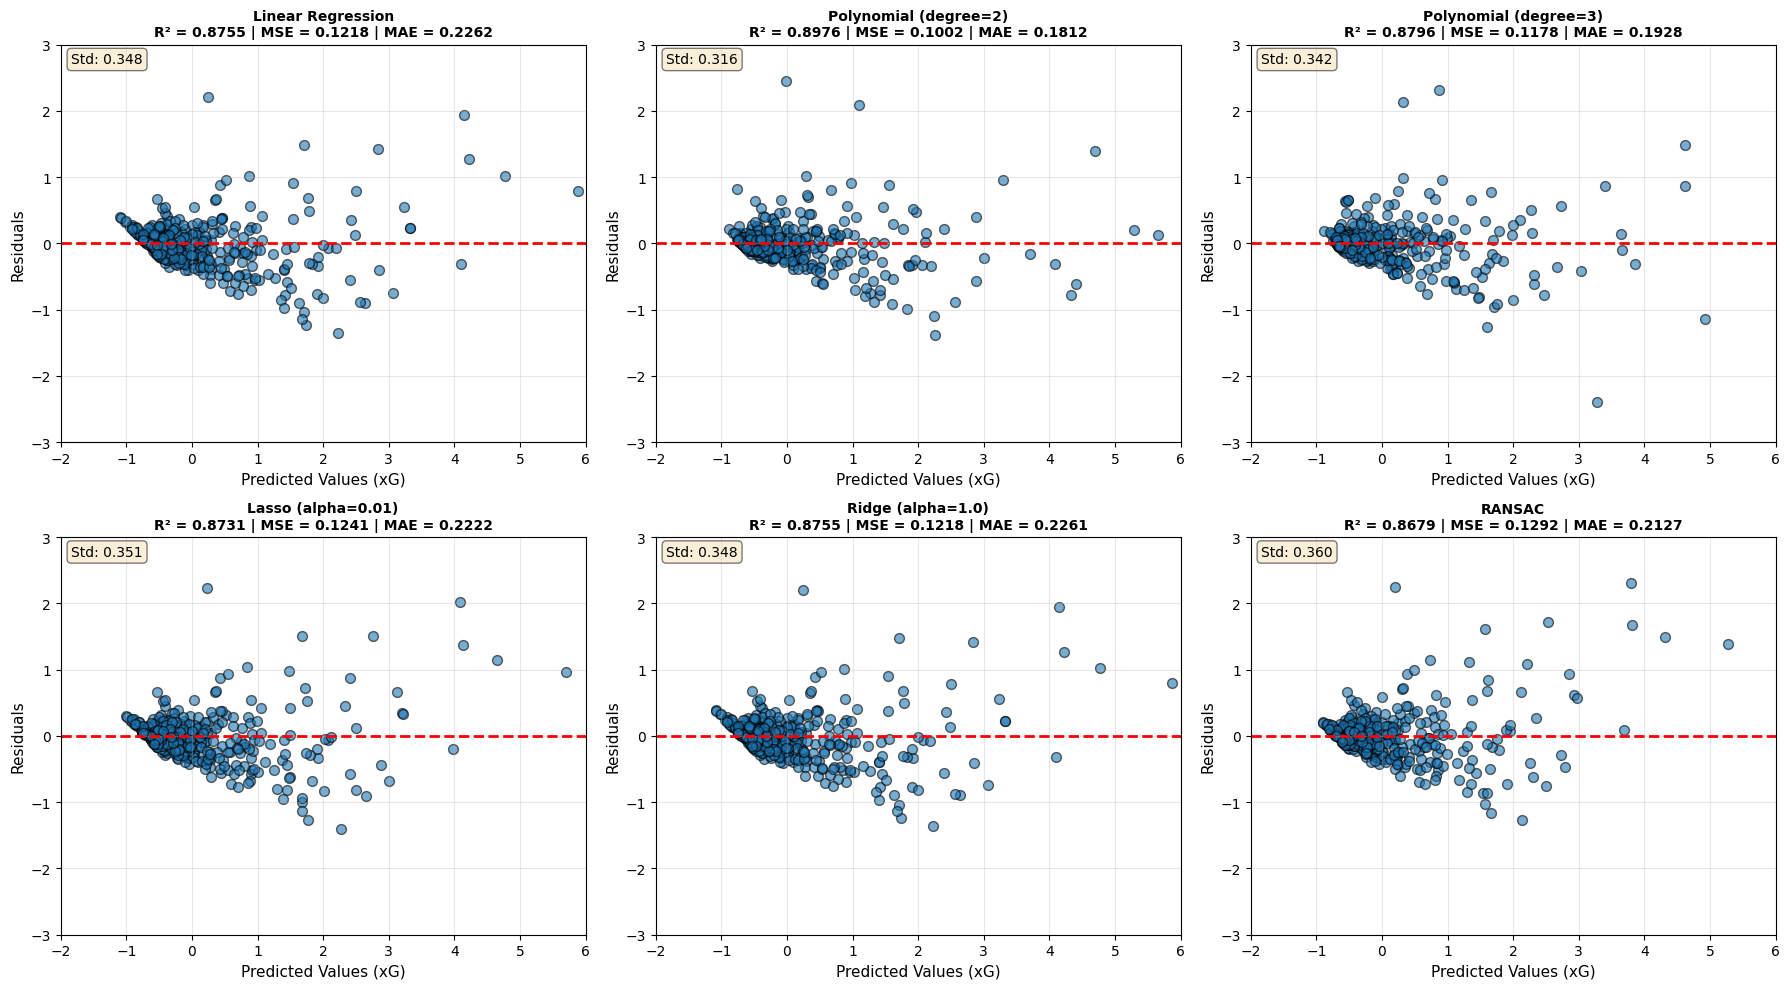

In [428]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, result in enumerate(results_list):
    
    residuals = y_test.values - result['y_test_pred']
    
    axes[idx].scatter(result['y_test_pred'], residuals, 
                     alpha=0.6, edgecolors='k', s=50)
    
    axes[idx].axhline(y=0, color='r', linestyle='--', linewidth=2)

    axes[idx].set_xlim(-2, 6)   
    axes[idx].set_ylim(-3, 3)  
    
    axes[idx].set_xlabel('Predicted Values (xG)', fontsize=11)
    axes[idx].set_ylabel('Residuals', fontsize=11)
    
    axes[idx].set_title(
        f"{result['name']}\n"
        f"R² = {result['test_r2']:.4f} | "
        f"MSE = {result['test_mse']:.4f} | "
        f"MAE = {result['test_mae']:.4f}",
        fontsize=10, fontweight='bold'
    )
    axes[idx].grid(True, alpha=0.3)
    std_residuals = np.std(residuals)
    axes[idx].text(0.02, 0.98, f'Std: {std_residuals:.3f}',transform=axes[idx].transAxes,
                  verticalalignment='top',bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

### По графикам можно сделать важные выводы:
остатки распределены вокруг 0, то есть модель в среднем не смещена
мы видем что у нас получается "веер" разброс увеличивается при увелечение xG, что означает модель более точно предсказывает малое количество голов и менее точно большое . Причина в том, что у нападающих разный стиль: одни создают моменты за счет большого количества ударов издалека (высокий Sh, низкий SoT%), другие - за счет редких, но качественных ударов вблизи ворот (низкий Sh, высокий SoT%).Несмотря на все, в итоге оценки коэффициентов остаются несмещенными, и модель достаточнг точна  (87%)

- Linear, Lasso, Ridge: модели не полностью ловит сложные зависимости между признаками и голами, из-за чего ошибки увеличиваются при высоких xG.
- Polynomial (degree=2): Остатки распределены более равномерно по сравнению с линейной моделью, 'веера' менее выражен. Это лучший график среди всех моделей. Модель улавливает нелинейные зависимости без существенного переобучения 
- Polynomial (degree=3): График остатков схож с Pol(degree=2), но разброс чуть больше (Std = 0.342 против 0.316). Несмотря на более высокую сложность модели, точность по R2 почти одинаковая, что означает что нам нет смысла брать полиномы большей степени.
- RANSAC: Остатки менее сконцентрированы вблизи нуля и демонстрируют больший общий разброс по сравнению c другими моделями. При построение модели она не учитывает аномалии, потоэтому на графике мало выбрасов. Однако в близи 0 остатки более разбросаны, что доказывает что модель менее гибкая.

В результате анализа шести моделей регрессии установлено, что полиномиальная регрессия второй степени показала наилучшее соотношение точности и устойчивости (Test R2 = 0.8976). Линейные модели и RANSAC получили качество (R2 = 0.86-0.88), однако уступают Polynomial (degree=2) по равномерности распределения остатков.

Анализ графиков показал, что разброс ошибок увеличивается с ростом предсказанного значения xG: модель точнее работает на малых значениях и менее точно - на больших. Это является особенностью футбольных данных.

Подберем гиперпараметры для проверки, что мы не упускаем что-то в точности моделей.

In [453]:
results_list.append(evaluate_model(
    "Ridge (alpha=1.0)",
    Ridge(alpha=1.0, random_state=22),
    X_train, X_test, y_train, y_test
))

Ridge (alpha=1.0)
Метрика         Train           Test           
MSE             0.1374          0.1218         
MAE             0.2262          0.2261         
R2              0.8634          0.8755         


In [465]:
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=22, max_iter=10000)
lasso_cv.fit(X_train, y_train)
print("LASSO подбор alpha")
print(f"Лучший alpha: {lasso_cv.alpha_:.4f}")
print(f"Train R2: {lasso_cv.score(X_train, y_train):.4f}")
print(f"Test R2: {lasso_cv.score(X_test, y_test):.4f}")

LASSO подбор alpha
Лучший alpha: 0.0002
Train R2: 0.8634
Test R2: 0.8754


В принцепе у нас получилось почти такая же точность, полином второй степени все равно лучше по точности.

# Задание 3

#### KMeans

In [370]:
from sklearn.cluster import KMeans

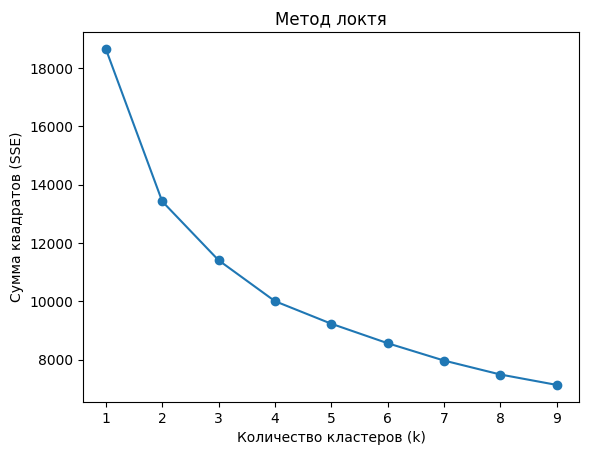

In [332]:
inertia = []

K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Сумма квадратов (SSE)')
plt.title('Метод локтя')
plt.show()

По графику метода локтя наблюдается излом в районе k = 2 - 3, что показывает оптимальное количество кластеров. Это и логично, так как после отчистки датасета у нас удалились вратари, у них не было параметров DIST и другие атакующие показатели, поэтому у нас игроки: защитники, полузащитники и нападающие.
Или разделаить на два нападающих и защитников потому что полузащитники - это игроки, которые может быть разный стиль оборона или нападение.

In [365]:
from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=2, random_state=22)
clusters_kmeans = kmeans.fit_predict(X)
df_clean['cluster_kmeans'] = clusters_kmeans
score = silhouette_score(X, clusters_kmeans)
print("Силуэтный коэффициент 2 кластера:", score)

Силуэтный коэффициент 2 кластера: 0.27391168720249176


In [367]:
from sklearn.metrics import silhouette_score
kmeans = KMeans(n_clusters=3, random_state=22)
clusters_kmeans = kmeans.fit_predict(X)
df_clean['cluster_kmeans'] = clusters_kmeans
score = silhouette_score(X, clusters_kmeans)
print("Силуэтный коэффициент 3 кластера:", score)

Силуэтный коэффициент 3 кластера: 0.1613640516284838


Для кластеризации игроков было выбрано k=2 кластера, поскольку силуэтный коэффициент при k=2 составляет 0.274, что на 70% выше, чем при k=3 (0.161).

In [368]:
kmeans = KMeans(n_clusters=2, random_state=22)
clusters_kmeans = kmeans.fit_predict(X)

df_clean['cluster_kmeans'] = clusters_kmeans

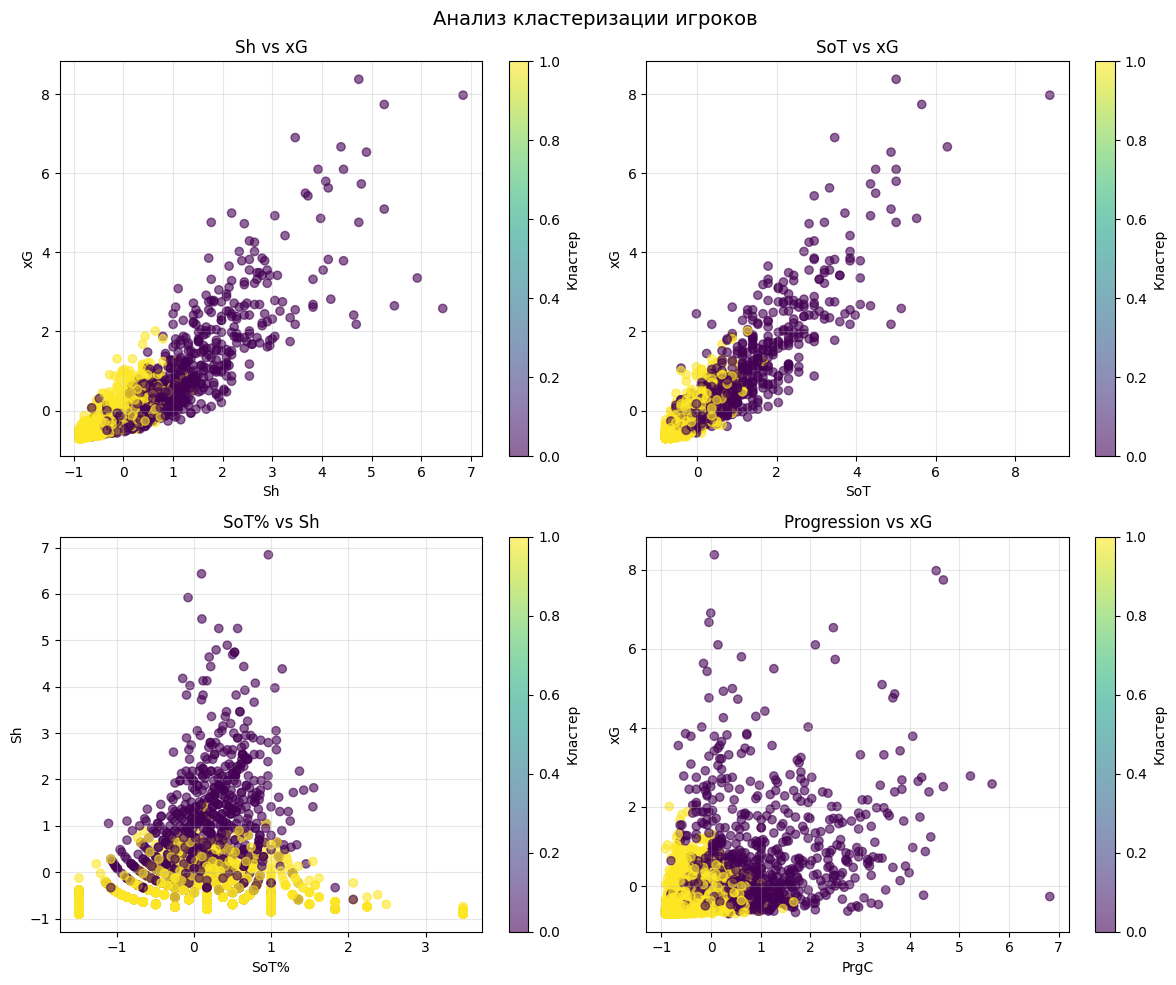

In [369]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

scatter1 = axes[0, 0].scatter(df_clean['Sh'], df_clean['xG'], 
                               c=df_clean['cluster_kmeans'], cmap='viridis', alpha=0.6)
axes[0, 0].set_xlabel('Sh')
axes[0, 0].set_ylabel('xG')
axes[0, 0].set_title('Sh vs xG')
axes[0, 0].grid(True, alpha=0.3)
fig.colorbar(scatter1, ax=axes[0, 0], label='Кластер')

scatter2 = axes[0, 1].scatter(df_clean['SoT'], df_clean['xG'], 
                               c=df_clean['cluster_kmeans'], cmap='viridis', alpha=0.6)
axes[0, 1].set_xlabel('SoT')
axes[0, 1].set_ylabel('xG')
axes[0, 1].set_title('SoT vs xG')
axes[0, 1].grid(True, alpha=0.3)
fig.colorbar(scatter2, ax=axes[0, 1], label='Кластер')

scatter3 = axes[1, 0].scatter(df_clean['SoT%'], df_clean['Sh'], 
                               c=df_clean['cluster_kmeans'], cmap='viridis', alpha=0.6)
axes[1, 0].set_xlabel('SoT%')
axes[1, 0].set_ylabel('Sh')
axes[1, 0].set_title('SoT% vs Sh')
axes[1, 0].grid(True, alpha=0.3)
fig.colorbar(scatter3, ax=axes[1, 0], label='Кластер')

scatter4 = axes[1, 1].scatter(df_clean['PrgC'], df_clean['xG'], 
                               c=df_clean['cluster_kmeans'], cmap='viridis', alpha=0.6)
axes[1, 1].set_xlabel('PrgC')
axes[1, 1].set_ylabel('xG')
axes[1, 1].set_title('Progression vs xG')
axes[1, 1].grid(True, alpha=0.3)
fig.colorbar(scatter4, ax=axes[1, 1], label='Кластер')

plt.suptitle('Анализ кластеризации игроков', fontsize=14)
plt.tight_layout()
plt.show()

Кластеризация KMeans с k=3 успешно разделила игроков на три группы в соответствии с футбольными позициями:

- Кластер 0 (желтый) - Защитники: минимальная атакующая активность, очень компактная группа, основная роль - оборона.

- Кластер 1 (фиолетовый) — Нападающие: максимальная атакующая активность, сильно разбросанная группа (большое разнообразие стилей игры), основная роль - атака.

График SoT% vs Sh показывает наилучшее разделение кластеров с минимальными пересечениями. Точность ударов (SoT%) варьируется внутри каждого кластера, что указывает что есть игроки с точными ударами на всех позициях, что логично. График "Progression vs xG" демонстрирует большее пересечения кластеров, что свидетельствует о том, что передачи менее четко коррелируют с позицией игрока.

#### DBSCAN

In [426]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = np.arange(0.1, 2.0, 0.1)
min_samples_values = range(2, 10)

results = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        clusters = dbscan.fit_predict(X)
        
        n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
        n_noise = list(clusters).count(-1)
        
        if n_clusters > 1 and n_noise < len(clusters) - 1:
            try:
                score = silhouette_score(X, clusters)
            except:
                score = -1
        else:
            score = -1
        
        results.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'noise_pct': n_noise / len(clusters) * 100,
            'silhouette': score
        })
df_results = pd.DataFrame(results)

best = df_results.loc[df_results['silhouette'].idxmax()]
print("лучшая комбинация:")
print(f"eps = {best['eps']:.2f}")
print(f"min_samples = {int(best['min_samples'])}")
print(f"Количество кластеров: {int(best['n_clusters'])}")
print(f"Процент шума: {best['noise_pct']:.1f}%")
print(f"Силуэтный коэффициент: {best['silhouette']:.4f}")

лучшая комбинация:
eps = 1.90
min_samples = 7
Количество кластеров: 2
Процент шума: 0.8%
Силуэтный коэффициент: 0.5030


Для кластеризации методом DBSCAN были подобраны оптимальные параметры путём перебора различных комбинаций eps (радиус окрестности) и min_samples (минимальное количество точек для формирования кластера). Лучшая комбинация параметров: eps = 1.90, min_samples = 7.

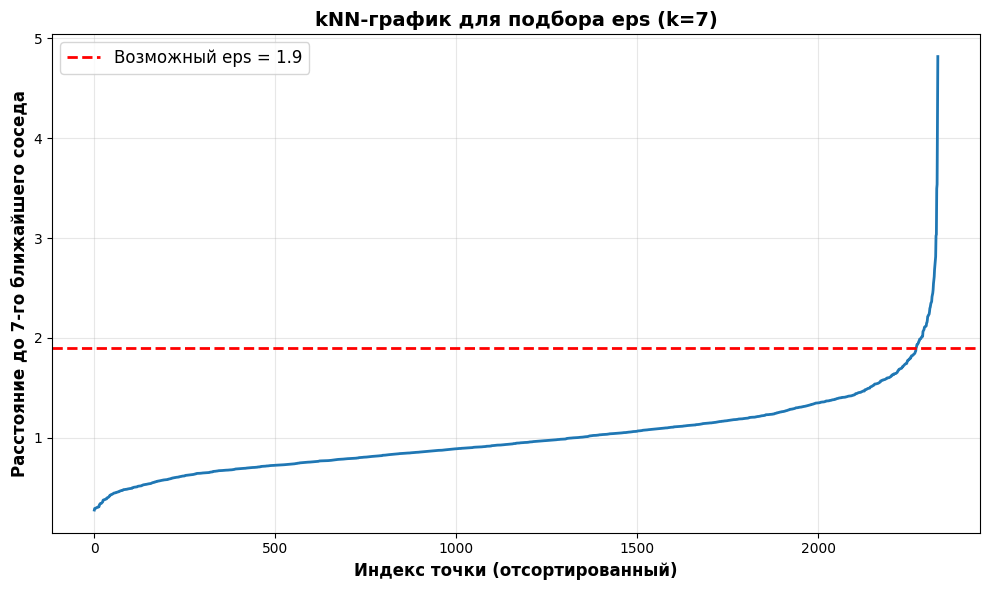

In [427]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt


k = 7

neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X) 
distances, indices = neighbors_fit.kneighbors(X)

distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances, linewidth=2)
plt.xlabel('Индекс точки (отсортированный)', fontsize=12, fontweight='bold')
plt.ylabel(f'Расстояние до {k}-го ближайшего соседа', fontsize=12, fontweight='bold')
plt.title(f'kNN-график для подбора eps (k={k})', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(y=1.9, color='red', linestyle='--', linewidth=2, label='Возможный eps = 1.9')
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

Подтверждение по графику, что это оптимальное значение.

In [421]:
dbscan = DBSCAN(eps=1.90, min_samples=7)
clusters_db = dbscan.fit_predict(X)

df_clean['cluster_dbscan'] = clusters_db

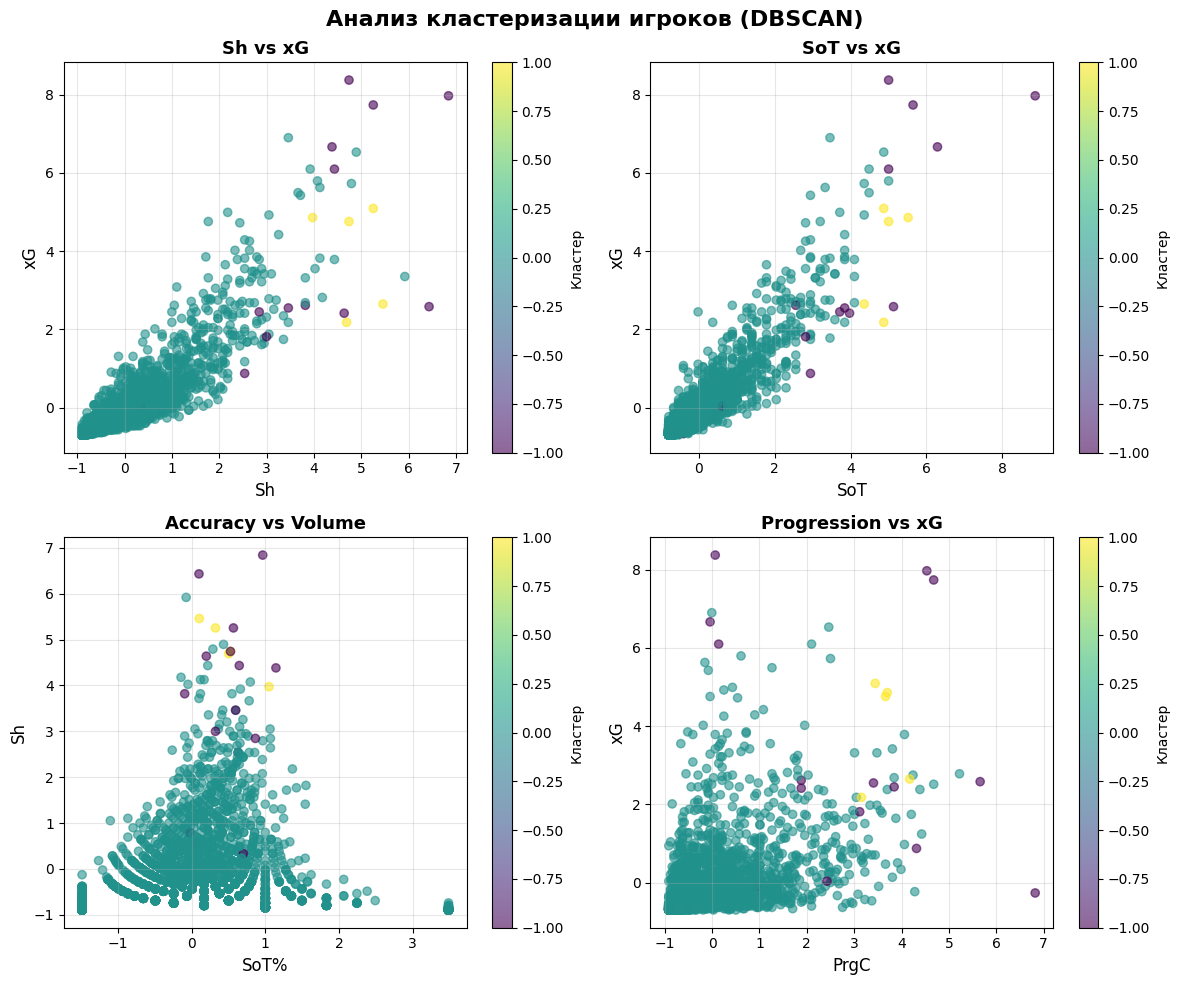

In [424]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

scatter1 = axes[0, 0].scatter(df_clean['Sh'], df_clean['xG'], 
                               c=df_clean['cluster_dbscan'], cmap='viridis', alpha=0.6)
axes[0, 0].set_xlabel('Sh', fontsize=12)
axes[0, 0].set_ylabel('xG', fontsize=12)
axes[0, 0].set_title('Sh vs xG', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
fig.colorbar(scatter1, ax=axes[0, 0], label='Кластер')

scatter2 = axes[0, 1].scatter(df_clean['SoT'], df_clean['xG'], 
                               c=df_clean['cluster_dbscan'], cmap='viridis', alpha=0.6)
axes[0, 1].set_xlabel('SoT', fontsize=12)
axes[0, 1].set_ylabel('xG', fontsize=12)
axes[0, 1].set_title('SoT vs xG', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
fig.colorbar(scatter2, ax=axes[0, 1], label='Кластер')

scatter3 = axes[1, 0].scatter(df_clean['SoT%'], df_clean['Sh'], 
                               c=df_clean['cluster_dbscan'], cmap='viridis', alpha=0.6)
axes[1, 0].set_xlabel('SoT%', fontsize=12)
axes[1, 0].set_ylabel('Sh', fontsize=12)
axes[1, 0].set_title('Accuracy vs Volume', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
fig.colorbar(scatter3, ax=axes[1, 0], label='Кластер')

scatter4 = axes[1, 1].scatter(df_clean['PrgC'], df_clean['xG'], 
                               c=df_clean['cluster_dbscan'], cmap='viridis', alpha=0.6)
axes[1, 1].set_xlabel('PrgC', fontsize=12)
axes[1, 1].set_ylabel('xG', fontsize=12)
axes[1, 1].set_title('Progression vs xG', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
fig.colorbar(scatter4, ax=axes[1, 1], label='Кластер')

plt.suptitle('Анализ кластеризации игроков (DBSCAN)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Кластеризация DBSCAN показала, что в выбранном признаковом пространстве не наблюдается выраженной дискретной структуры игроков, соответствующей чётко отделимым классам.

При оптимальных параметрах (eps = 1.9, min_samples = 7), выбранных по максимальному силуэтном коэффициенту, алгоритм выделяет 2 кластера: один крупный и плотный, включающий подавляющее большинство игроков, и второй - маленький, состоящий из редких наблюдений и аномальных значений. Процент шума при этом минимален, что указывает на почти полное “покрытие” данных основным кластером.

Признаки (Sh, SoT, xG, PrgC, PrgP) показывает ключевую причину такого результата: данные формируют непрерывное распределение без естественных разрывов. Все основные атакующие метрики и показатели вовлечённости в игру изменяются согласованно - с ростом количества ударов (Sh) растут SoT и xG, а также показатели продвижения мяча (PrgC, PrgP).

Из-за этого отсутствуют “дыр” в пространстве признаков: вокруг каждой точки всегда можно найти соседние объекты с близкими характеристиками. Поэтому при увеличении eps области плотности расширяются постепенно и сливаются в единый крупный кластер, а не формируют устойчивое разделение на несколько классов.В сравнении с методом KMeans, где заранее задаётся количество кластеров и происходит принудительное разбиение пространства.

Поэтому DBSCAN  возвращает 2-3 кластера даже при переборе параметров. Фактически, найденные оптимальные eps и min_samples уже дают максимально возможное разделение для данной структуры данных, и дальнейшая настройка параметров не приводит к появлению новых устойчивых кластеров.

Таким образом, можно сделать вывод, что улучшить результат кластеризации в рамках DBSCAN без изменения признаков невозможно - ограничение связано не с параметрами алгоритма, а с самой стуктуры данных.